In [1]:
# ============================================================
# Bootstrap Estatístico: Do Conceito à Aplicação Prática
# ============================================================
# Este notebook implementa os principais métodos bootstrap para
# inferência estatística, cobrindo:
#   1. Bootstrap não-paramétrico básico (mediana)
#   2. Bootstrap de resíduos e de casos em regressão linear
#   3. Wild bootstrap para dados heterocedásticos
#   4. Métodos de intervalo de confiança (percentil, BC)
#   5. Testes de hipótese (uma amostra, dois grupos, A/B test)
# ============================================================

import numpy as np                # Computação numérica e reamostragem
import matplotlib.pyplot as plt   # Visualização de gráficos
import seaborn as sns             # Estilos e paletas de cores

In [2]:
# ------------------------------------------------------------
# Configurações globais de visualização e reprodutibilidade
# ------------------------------------------------------------
# 'seaborn-v0_8-whitegrid': fundo limpo com grade suave
# 'colorblind': paleta acessível para daltônicos
# seed(42): garante que os resultados são reproduzíveis em qualquer máquina
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("colorblind")
np.random.seed(42)


# O basico do bootstrap

In [3]:
# ------------------------------------------------------------
# Simulação dos dados: receita mensal por cliente (em R$)
# ------------------------------------------------------------
# Usamos uma distribuição log-normal porque receita é tipicamente:
#   - Sempre positiva (não existe receita negativa)
#   - Assimétrica à direita (poucos clientes gastam muito)
#   - Bem modelada por log-normal em cenários de negócios
#
# Parâmetros da log-normal:
#   mean=5.8 → mediana ≈ e^5.8 ≈ R$ 330 (mediana de log(X), não de X)
#   sigma=0.7 → dispersão moderada nos dados
n = 50
receita_clientes = np.random.lognormal(mean=5.8, sigma=0.7, size=n)
receita_clientes = np.round(receita_clientes, 2)

# Estatísticas descritivas da amostra
# Note como média > mediana, confirmando a assimetria à direita
print(f"Tamanho da amostra: {n}")
print(f"Média amostral: R$ {np.mean(receita_clientes):.2f}")
print(f"Mediana amostral: R$ {np.median(receita_clientes):.2f}")
print(f"Desvio padrão amostral: R$ {np.std(receita_clientes, ddof=1):.2f}")


Tamanho da amostra: 50
Média amostral: R$ 348.66
Mediana amostral: R$ 280.37
Desvio padrão amostral: R$ 248.57


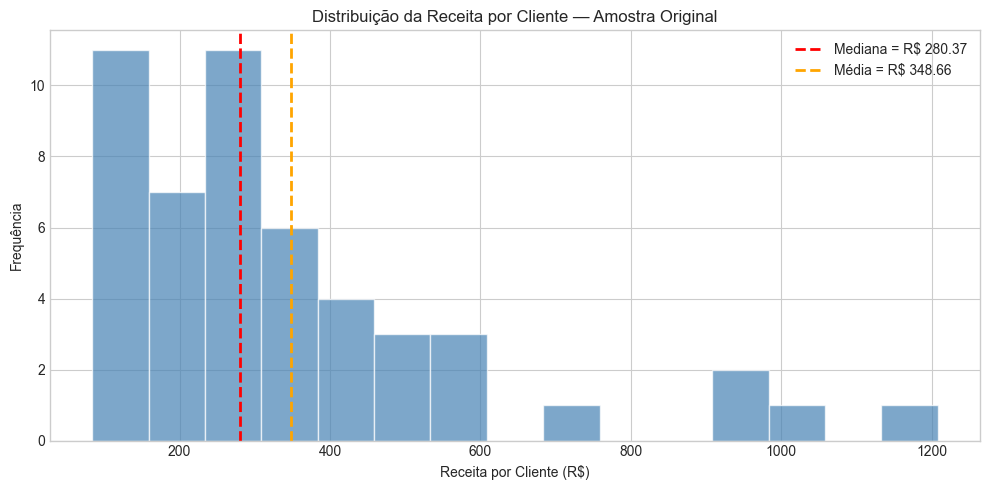

In [4]:
# ------------------------------------------------------------
# Visualização da distribuição original
# ------------------------------------------------------------
# A diferença entre média e mediana evidencia a assimetria.
# Em dados assimétricos como este, a mediana é frequentemente uma
# estatística mais robusta — e é exatamente onde o bootstrap é util,
# pois não existe fórmula analítica simples para o erro padrão da mediana.
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(receita_clientes, bins=15, edgecolor='white', alpha=0.7, color='steelblue')
ax.axvline(np.median(receita_clientes), color='red', linestyle='--', linewidth=2,
           label=f'Mediana = R$ {np.median(receita_clientes):.2f}')
ax.axvline(np.mean(receita_clientes), color='orange', linestyle='--', linewidth=2,
           label=f'Média = R$ {np.mean(receita_clientes):.2f}')
ax.set_xlabel('Receita por Cliente (R$)')
ax.set_ylabel('Frequência')
ax.set_title('Distribuição da Receita por Cliente — Amostra Original')
ax.legend()
plt.tight_layout()
plt.show()


In [5]:
# ------------------------------------------------------------
# Uma única reamostra bootstrap
# ------------------------------------------------------------
# O bootstrap funciona por reamostragem com reposição:
#   - Sorteamos n observações da amostra original, com reposição
#   - Cada reamostra tem o mesmo tamanho n da amostra original
#   - Algumas observações aparecem mais de uma vez; outras não aparecem
#
reamostra_1 = np.random.choice(receita_clientes, size=n, replace=True)

print(f"Amostra original - Mediana: R$ {np.median(receita_clientes):.2f}")
print(f"Reamostra 1      - Mediana: R$ {np.median(reamostra_1):.2f}")

# Verificando a proporção de observações únicas (~63%)
n_unicos = len(np.unique(reamostra_1))
print(f"\nObservações únicas na reamostra: {n_unicos} de {n} ({n_unicos/n*100:.1f}%)")

Amostra original - Mediana: R$ 280.37
Reamostra 1      - Mediana: R$ 336.74

Observações únicas na reamostra: 31 de 50 (62.0%)


In [6]:
# ------------------------------------------------------------
# Intuição: como a mediana varia entre reamostras
# ------------------------------------------------------------
# Cada reamostra gera uma mediana ligeiramente diferente.
# Essa variabilidade é a essência do bootstrap: ela aproxima
# a verdadeira variabilidade amostral da estatística.
print("Medianas de 5 reamostras bootstrap:")
for i in range(5):
    reamostra = np.random.choice(receita_clientes, size=n, replace=True)
    med = np.median(reamostra)
    print(f"  Reamostra {i+1}: R$ {med:.2f}")


Medianas de 5 reamostras bootstrap:
  Reamostra 1: R$ 290.92
  Reamostra 2: R$ 299.83
  Reamostra 3: R$ 351.63
  Reamostra 4: R$ 275.65
  Reamostra 5: R$ 327.19


In [7]:
# ------------------------------------------------------------
# Loop bootstrap completo: B = 10.000 reamostras
# ------------------------------------------------------------
# Algoritmo:
#   Para b = 1, 2, ..., B:
#     1. Reamostre n observações com reposição → amostra*_b
#     2. Calcule a estatística de interesse → θ̂*_b = mediana(amostra*_b)
#   Resultado: distribuição bootstrap {θ̂*_1, ..., θ̂*_B}
#
# B = 10.000 é suficiente para a maioria das aplicações.
# Para ICs, B ≥ 1.000 é razoável; para p-values, B ≥ 5.000.
B = 10_000
medianas_bootstrap = np.empty(B)

for i in range(B):
    reamostra = np.random.choice(receita_clientes, size=n, replace=True)
    medianas_bootstrap[i] = np.median(reamostra)

# O erro padrão bootstrap é o desvio padrão da distribuição bootstrap
# Ele estima o erro padrão da mediana amostral sem fórmulas analíticas
print(f"Mediana original:       R$ {np.median(receita_clientes):.2f}")
print(f"Média das medianas BS:  R$ {np.mean(medianas_bootstrap):.2f}")
print(f"Erro padrão bootstrap:  R$ {np.std(medianas_bootstrap, ddof=1):.2f}")

Mediana original:       R$ 280.37
Média das medianas BS:  R$ 281.46
Erro padrão bootstrap:  R$ 31.69


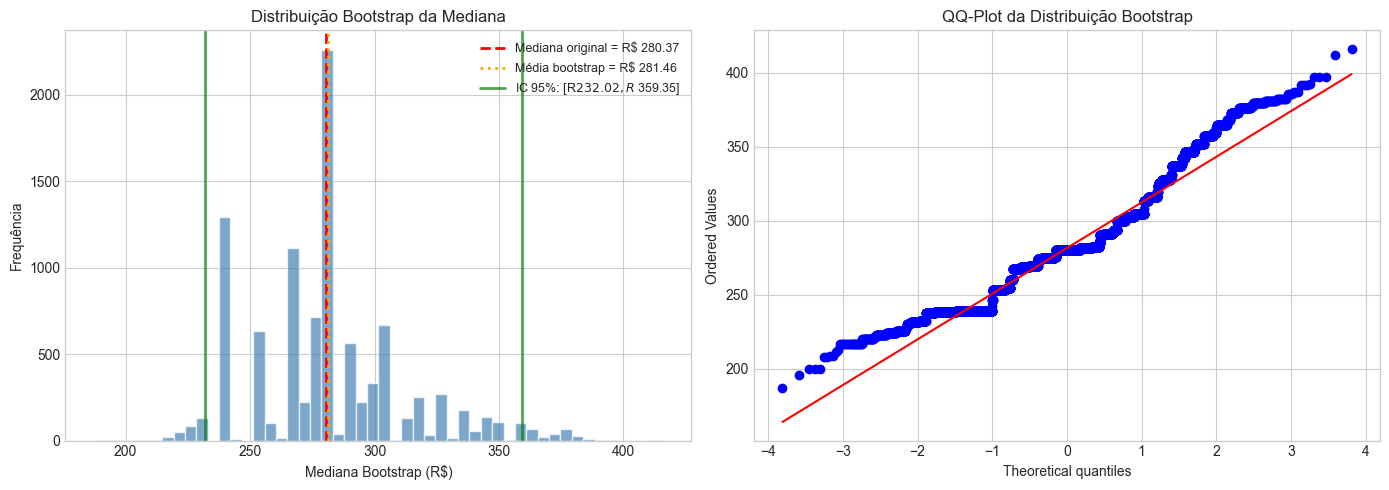

Resumo
Estatística original (mediana): R$ 280.37
Erro padrão bootstrap:          R$ 31.69
Viés/Desvio do bootstrap:                 R$ 1.09
IC 95% (percentil):             [R$ 232.02, R$ 359.35]
Largura do IC:                  R$ 127.32


In [8]:
# ------------------------------------------------------------
# Distribuição bootstrap da mediana + diagnóstico de normalidade
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Painel esquerdo: histograma da distribuição bootstrap
# A distribuição bootstrap aproxima a distribuição amostral da mediana
axes[0].hist(medianas_bootstrap, bins=50, edgecolor='white', alpha=0.7, color='steelblue')
axes[0].axvline(np.median(receita_clientes), color='red', linestyle='--', linewidth=2,
                label=f'Mediana original = R$ {np.median(receita_clientes):.2f}')
axes[0].axvline(np.mean(medianas_bootstrap), color='orange', linestyle=':', linewidth=2,
                label=f'Média bootstrap = R$ {np.mean(medianas_bootstrap):.2f}')

# Intervalo de confiança pelo método percentil (2.5% e 97.5%)
ic_lower = np.percentile(medianas_bootstrap, 2.5)
ic_upper = np.percentile(medianas_bootstrap, 97.5)
axes[0].axvline(ic_lower, color='green', linestyle='-', linewidth=2, alpha=0.7)
axes[0].axvline(ic_upper, color='green', linestyle='-', linewidth=2, alpha=0.7,
                label=f'IC 95%: [R$ {ic_lower:.2f}, R$ {ic_upper:.2f}]')

axes[0].set_xlabel('Mediana Bootstrap (R$)')
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição Bootstrap da Mediana')
axes[0].legend(fontsize=9)

# Painel direito: QQ-plot
# Se a distribuição bootstrap for aproximadamente normal, os pontos
# seguirão a linha diagonal. Desvios indicam assimetria ou caudas pesadas.
from scipy import stats
stats.probplot(medianas_bootstrap, dist="norm", plot=axes[1])
axes[1].set_title('QQ-Plot da Distribuição Bootstrap')

plt.tight_layout()
plt.show()

# Resumo numérico completo
# O viés bootstrap mede a diferença entre a média das estimativas
# bootstrap e a estatística original. Viés ≈ 0 indica boa performance.
print("=" * 50)
print("Resumo")
print("=" * 50)
print(f"Estatística original (mediana): R$ {np.median(receita_clientes):.2f}")
print(f"Erro padrão bootstrap:          R$ {np.std(medianas_bootstrap, ddof=1):.2f}")
print(f"Viés/Desvio do bootstrap:                 R$ {np.mean(medianas_bootstrap) - np.median(receita_clientes):.2f}")
print(f"IC 95% (percentil):             [R$ {ic_lower:.2f}, R$ {ic_upper:.2f}]")
print(f"Largura do IC:                  R$ {ic_upper - ic_lower:.2f}")

## Funcionamento do metodo


A medida que o tamanho da amostra cresce, a distribuição dos dados observados se torna uma cópia cada vez mais fiel da distribuição real. Se F̂ₙ ≈ F, então reamostrar de F̂ₙ é "quase como" amostrar de F.

**A Relação com a Lei dos Grandes Números e o TCL**

A Lei dos Grandes Números garante que as estatísticas calculadas da amostra convergem para os parâmetros populacionais
O Teorema Central do Limite garante que a distribuição amostral de muitas estatísticas é aproximadamente normal para n grande
O bootstrap não depende do TCL para funcionar, mas quando o TCL se aplica, a distribuição bootstrap e a distribuição amostral teórica tendem a concordar

**Condições Necessárias**

O bootstrap funciona bem quando:

* A amostra é representativa — observações são i.i.d. (independentes e identicamente distribuídas) da população de interesse

* O tamanho amostral é suficiente — regra prática: n ≥ 20-30 para estatísticas suaves (média, regressão); mais para estatísticas não-suaves (quantis extremos)

* A estatística é "suave" — pequenas mudanças nos dados produzem pequenas mudanças na estatística (a média é suave; o máximo não é)

**Quando o Bootstrap não é tao util**

* Distribuições de cauda pesada sem variância finita

* Estatísticas de extremos — o bootstrap para o máximo ou mínimo amostral é inconsistente. 

* Dados dependentes tratados como independentes

* Amostras muito pequenas (n < 10-15) 

As duas perguntas que você deve sempre fazer antes de usar bootstrap:

* Meus dados são independentes?

* Minha estatística é suave? Se é algo como "máximo", "mínimo", ou um quantil muito extremo (percentil 99.9), o bootstrap pode ser problemático.

In [9]:
# ------------------------------------------------------------
# Bootstrap usando scipy.stats.bootstrap (implementação pronta)
# ------------------------------------------------------------
# Na prática, não precisamos escrever o loop manualmente.
# O scipy oferece uma implementação otimizada que suporta:
#   - Vários métodos de IC (percentile, basic, BCa)
#   - Paralelização e vetorização
#   - Cálculo automático do erro padrão
#
# Nota: a API espera 'data' como tupla de arrays e 'statistic'
# como função que aceita o array e retorna um escalar.
from scipy.stats import bootstrap as sp_bootstrap

resultado_scipy = sp_bootstrap(
    data=(receita_clientes,),        # Tupla com o(s) array(s) de dados
    statistic=np.median,             # Estatística de interesse
    n_resamples=10_000,              # Número de reamostras (B)
    confidence_level=0.95,           # Nível de confiança do IC
    random_state=42,                 # Reprodutibilidade
    method='percentile'              # Método do IC: 'percentile', 'basic', ou 'BCa' -> padrao é BCa
)

print(f"IC 95% (scipy percentile): [{resultado_scipy.confidence_interval.low:.2f}, "
      f"{resultado_scipy.confidence_interval.high:.2f}]")
print(f"Erro padrão bootstrap: {resultado_scipy.standard_error:.2f}")

IC 95% (scipy percentile): [231.71, 359.35]
Erro padrão bootstrap: 31.85


# Residual bootstrap

Quando trabalhamos com regressão, temos duas opções de bootstrap:

* Bootstrap de casos (case resampling): reamostre pares (xᵢ, yᵢ) completos — é o bootstrap não-paramétrico aplicado a regressão
* Bootstrap de resíduos (residual bootstrap): ajuste o modelo, calcule os resíduos, reamostre os resíduos, e reconstrua novos y's

Quando usar cada um:

* Casos: Quando a relação entre X e Y pode ser não-linear, ou quando X não é fixo (X é aleatório). Mais robusto, menos eficiente.
* Resíduos: Quando o modelo linear é correto e os erros são i.i.d. Mais eficiente, mais suposições.

In [10]:
# ============================================================
# Bootstrap em Regressão Linear: preparação dos dados
# ============================================================
# Cenário: relação entre gasto em marketing e receita.
# Simulamos dados com relação linear + ruído gaussiano.
#   y = 50 + 2.5 * x + ε, onde ε ~ N(0, 25)
#
# O modelo OLS nos dá estimativas pontuais e ICs paramétricos
# (baseados na suposição de normalidade dos erros).
# O bootstrap nos permite estimar a incerteza sem essa suposição.
import statsmodels.api as sm

np.random.seed(42)
n_reg = 80
marketing = np.random.uniform(10, 100, n_reg)                  # Gasto em marketing (variável X)
receita_reg = 50 + 2.5 * marketing + np.random.normal(0, 25, n_reg)  # Receita (variável Y)

# Ajuste do modelo OLS (Ordinary Least Squares) com intercepto
X = sm.add_constant(marketing)   # Adiciona coluna de 1s para o intercepto
modelo = sm.OLS(receita_reg, X).fit()
print(modelo.summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         43.2797      5.760      7.514      0.000      31.812      54.747
x1             2.6248      0.098     26.743      0.000       2.429       2.820


In [11]:
# ------------------------------------------------------------
# Bootstrap de Resíduos (Residual Bootstrap)
# ------------------------------------------------------------
# Algoritmo:
#   1. Ajuste o modelo OLS original → obtenha ŷ e resíduos ê
#   2. Para b = 1, ..., B:
#      a. Reamostre os resíduos com reposição → ê*
#      b. Construa novos y*: y*_i = ŷ_i + ê*_i
#      c. Reajuste OLS com (X, y*) → armazene os coeficientes
#
# Premissa: os erros são i.i.d. (mesma distribuição para todos i).
# Vantagem: preserva a estrutura de X (X é fixo, apenas os erros variam).
B = 5_000
residuos = modelo.resid       # Resíduos do modelo original: ê = y - ŷ
y_hat = modelo.fittedvalues   # Valores ajustados: ŷ = Xβ̂
coefs_resid_bs = np.empty((B, 2))  # Armazena [intercepto, slope] para cada reamostra

rng = np.random.default_rng(42)
for i in range(B):
    # Reamostra os resíduos (com reposição) e reconstrói y
    residuos_reamostrados = rng.choice(residuos, size=n_reg, replace=True)
    y_novo = y_hat + residuos_reamostrados
    modelo_bs = sm.OLS(y_novo, X).fit()
    coefs_resid_bs[i] = modelo_bs.params

In [12]:
# ------------------------------------------------------------
# Bootstrap de Casos (Case/Pairs Bootstrap)
# ------------------------------------------------------------
# Algoritmo:
#   1. Para b = 1, ..., B:
#      a. Reamostre os índices {1, ..., n} com reposição → idx*
#      b. Use X[idx*] e y[idx*] como novos dados
#      c. Reajuste OLS → armazene os coeficientes
#
# Premissa: os pares (xᵢ, yᵢ) são i.i.d. — tanto X quanto Y são aleatórios.
# Vantagem: não assume homocedasticidade nem linearidade estrita.
# Desvantagem: menos eficiente que o bootstrap de resíduos quando o modelo é correto.
coefs_casos_bs = np.empty((B, 2))
for i in range(B):
    idx = rng.choice(n_reg, size=n_reg, replace=True)  # Índices reamostrados
    X_bs = X[idx]
    y_bs = receita_reg[idx]
    modelo_bs = sm.OLS(y_bs, X_bs).fit()
    coefs_casos_bs[i] = modelo_bs.params


IC 95% para o coeficiente de Marketing (slope)
OLS paramétrico:      [2.429, 2.820]
Bootstrap resíduos:   [2.438, 2.823]
Bootstrap casos:      [2.430, 2.830]


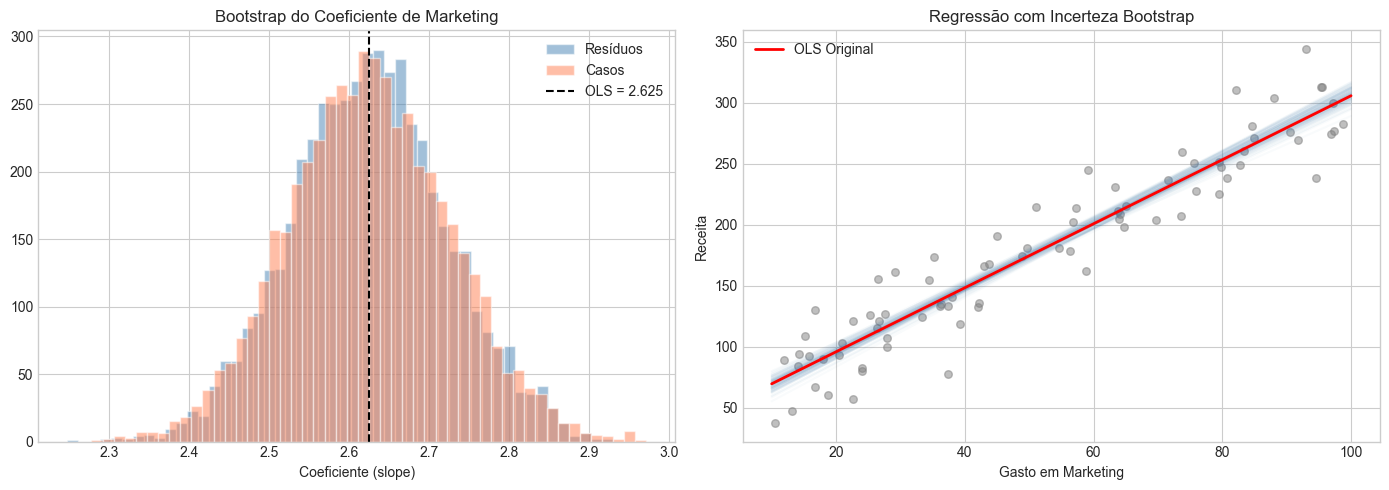

In [13]:
# ------------------------------------------------------------
# Comparação: OLS paramétrico vs. Bootstrap (resíduos e casos)
# ------------------------------------------------------------
# Os três métodos devem concordar quando as suposições do OLS
# são satisfeitas (erros normais, homocedasticidade). Diferenças
# indicam que as suposições paramétricas podem estar incorretas.
print("\n" + "=" * 60)
print("IC 95% para o coeficiente de Marketing (slope)")
print("=" * 60)
print(f"OLS paramétrico:      [{modelo.conf_int()[1][0]:.3f}, {modelo.conf_int()[1][1]:.3f}]")
print(f"Bootstrap resíduos:   [{np.percentile(coefs_resid_bs[:, 1], 2.5):.3f}, "
      f"{np.percentile(coefs_resid_bs[:, 1], 97.5):.3f}]")
print(f"Bootstrap casos:      [{np.percentile(coefs_casos_bs[:, 1], 2.5):.3f}, "
      f"{np.percentile(coefs_casos_bs[:, 1], 97.5):.3f}]")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Painel esquerdo: distribuição bootstrap do coeficiente (slope)
# Resíduos (azul) tende a ser mais estreito que casos (coral),
# pois assume mais (erros i.i.d.) e é mais eficiente quando correto.
axes[0].hist(coefs_resid_bs[:, 1], bins=50, alpha=0.5, color='steelblue', label='Resíduos', edgecolor='white')
axes[0].hist(coefs_casos_bs[:, 1], bins=50, alpha=0.5, color='coral', label='Casos', edgecolor='white')
axes[0].axvline(modelo.params[1], color='black', linestyle='--', label=f'OLS = {modelo.params[1]:.3f}')
axes[0].legend()
axes[0].set_title('Bootstrap do Coeficiente de Marketing')
axes[0].set_xlabel('Coeficiente (slope)')

# Painel direito: scatter com bandas de incerteza bootstrap
# Cada linha semitransparente é uma regressão de uma reamostra.
# A "nuvem" de linhas mostra visualmente a incerteza da estimativa.
axes[1].scatter(marketing, receita_reg, alpha=0.5, s=30, color='gray')
x_plot = np.linspace(10, 100, 100)
for i in range(100):  # 100 linhas bootstrap aleatórias para visualização
    axes[1].plot(x_plot, coefs_casos_bs[i, 0] + coefs_casos_bs[i, 1] * x_plot,
                 color='steelblue', alpha=0.03)
axes[1].plot(x_plot, modelo.params[0] + modelo.params[1] * x_plot,
             color='red', linewidth=2, label='OLS Original')
axes[1].legend()
axes[1].set_title('Regressão com Incerteza Bootstrap')
axes[1].set_xlabel('Gasto em Marketing')
axes[1].set_ylabel('Receita')

plt.tight_layout()
plt.show()

# Wild bootstrap

O bootstrap de resíduos assume que os erros são i.i.d. — mesma variância para todas as observações (homocedasticidade). Na presença de heterocedasticidade (variância dos erros variando com X), o bootstrap de resíduos pode falhar.

O Wild Bootstrap resolve isso:

Ajuste o modelo e obtenha os resíduos ê

* Para cada observação, gere um peso aleatório w (tipicamente Rademacher: +1 ou -1 com probabilidade 0.5 cada)
* O novo resíduo é ê* = w × ê
* O novo y é ŷ + ê*

Elemento principal: ao multiplicar cada resíduo pelo peso aleatório (ao invés de reamostrar), preservamos o padrão de heterocedasticidade — resíduos grandes permanecem grandes, pequenos permanecem pequenos.

In [14]:
# ============================================================
# Wild Bootstrap: dados com heterocedasticidade
# ============================================================
# Simulamos dados onde a variância do erro cresce com X:
#   y = 10 + 3x + ε, onde ε ~ N(0, x²)
# Isso viola a suposição de homocedasticidade do OLS e do
# bootstrap de resíduos, mas o wild bootstrap lida com isso.
np.random.seed(42)
n_wild = 100
x_wild = np.random.uniform(1, 10, n_wild)

# σ(x) = x → variância cresce linearmente com x (heterocedástico)
y_wild = 10 + 3 * x_wild + np.random.normal(0, 1, n_wild) * x_wild

# Ajuste OLS (estimativas de β são consistentes mesmo com
# heterocedasticidade, mas os erros padrão/ICs são incorretos)
X_wild = sm.add_constant(x_wild)
modelo_wild = sm.OLS(y_wild, X_wild).fit()
residuos_wild = modelo_wild.resid
y_hat_wild = modelo_wild.fittedvalues

In [15]:
# ------------------------------------------------------------
# Wild Bootstrap com pesos Rademacher
# ------------------------------------------------------------
# Algoritmo:
#   1. Ajuste o modelo → obtenha ŷ e resíduos ê
#   2. Para b = 1, ..., B:
#      a. Gere pesos aleatórios w_i ∈ {-1, +1} com prob 0.5 cada (Rademacher)
#      b. Novos resíduos: ê*_i = w_i × ê_i
#      c. Novos y: y*_i = ŷ_i + ê*_i
#      d. Reajuste OLS → armazene os coeficientes
#
# Intuição: ao multiplicar (não reamostrar) cada resíduo por ±1,
# preservamos a magnitude local de cada resíduo (mantém o padrão
# de heterocedasticidade), mas variamos o sinal aleatoriamente.
B = 5_000
coefs_wild_bs = np.empty((B, 2))
rng = np.random.default_rng(42)

for i in range(B):
    w = rng.choice([-1, 1], size=n_wild)    # Pesos Rademacher: P(w=1) = P(w=-1) = 0.5
    residuos_novos = residuos_wild * w       # Preserva magnitude, aleatoriza sinal
    y_novo = y_hat_wild + residuos_novos
    modelo_bs = sm.OLS(y_novo, X_wild).fit()
    coefs_wild_bs[i] = modelo_bs.params

In [16]:
# ------------------------------------------------------------
# Bootstrap de resíduos padrão (para comparação)
# ------------------------------------------------------------
# Aqui reamostramos os resíduos de forma clássica (com reposição).
# Como os dados são heterocedásticos, este método não preserva o
# padrão de variância — resíduos grandes de x=10 podem ser atribuídos
# a observações com x=1, distorcendo a inferência.
coefs_resid_std = np.empty((B, 2))
for i in range(B):
    res_reamostrados = rng.choice(residuos_wild, size=n_wild, replace=True)
    y_novo = y_hat_wild + res_reamostrados
    modelo_bs = sm.OLS(y_novo, X_wild).fit()
    coefs_resid_std[i] = modelo_bs.params

In [17]:
# ------------------------------------------------------------
# OLS com erros padrão robustos à heterocedasticidade (HC3)
# ------------------------------------------------------------
# HC3 (MacKinnon & White, 1985) é o estimador de variância
# "sanduíche" mais usado na prática. Fornece erros padrão e ICs
# válidos mesmo sob heterocedasticidade, sem precisar de bootstrap.
# Serve aqui como benchmark para comparação.
modelo_hc = sm.OLS(y_wild, X_wild).fit(cov_type='HC3')

In [18]:
# ------------------------------------------------------------
# Comparação dos métodos sob heterocedasticidade
# ------------------------------------------------------------
# Esperamos que:
#   - OLS padrão: IC incorreto (subestima a incerteza)
#   - HC3: IC correto (robusto a heterocedasticidade)
#   - Bootstrap resíduos: IC incorreto (não preserva padrão de variância)
#   - Wild bootstrap: IC correto (preserva heterocedasticidade)
print("IC 95% para slope:")
print(f"  OLS padrão (incorreto se heterocedástico): "
      f"[{modelo_wild.conf_int()[1][0]:.3f}, {modelo_wild.conf_int()[1][1]:.3f}]")
print(f"  OLS com HC3:              [{modelo_hc.conf_int()[1][0]:.3f}, {modelo_hc.conf_int()[1][1]:.3f}]")
print(f"  Bootstrap resíduos:       [{np.percentile(coefs_resid_std[:, 1], 2.5):.3f}, "
      f"{np.percentile(coefs_resid_std[:, 1], 97.5):.3f}]")
print(f"  Wild Bootstrap:           [{np.percentile(coefs_wild_bs[:, 1], 2.5):.3f}, "
      f"{np.percentile(coefs_wild_bs[:, 1], 97.5):.3f}]")

IC 95% para slope:
  OLS padrão (incorreto se heterocedástico): [2.473, 3.248]
  OLS com HC3:              [2.436, 3.285]
  Bootstrap resíduos:       [2.491, 3.243]
  Wild Bootstrap:           [2.457, 3.272]


# Intervalos de confianca com bootstrap

## Metodo percentil

O método mais intuitivo: se temos B estimativas bootstrap θ̂₁, θ̂₂, ..., θ̂*_B, o IC 95% é simplesmente:

IC = [percentil 2.5% das θ̂*, percentil 97.5% das θ̂*]

In [19]:
# ------------------------------------------------------------
# Método Percentil: o IC bootstrap mais simples
# ------------------------------------------------------------
# Dado a distribuição bootstrap {θ̂*_1, ..., θ̂*_B}, o IC é:
#   IC(1-α) = [quantil(α/2), quantil(1 - α/2)]
#
# Para IC 95%: [percentil 2.5%, percentil 97.5%]
#
# Limitação: assume que a distribuição bootstrap é simétrica
# em torno de θ̂. Quando há viés, o método BC (abaixo) corrige.
def ic_percentil(bootstrap_dist, alpha=0.05):
    """IC bootstrap pelo método percentil."""
    lower = np.percentile(bootstrap_dist, 100 * alpha / 2)
    upper = np.percentile(bootstrap_dist, 100 * (1 - alpha / 2))
    return lower, upper

ic_perc = ic_percentil(medianas_bootstrap)
print(f"IC 95% Percentil: [{ic_perc[0]:.2f}, {ic_perc[1]:.2f}]")

IC 95% Percentil: [232.02, 359.35]


## Metodo com correcao de vies

O método percentil assume que a distribuição bootstrap é centrada em θ̂. 

Quando não é (viés), corrigimos.
A correção de viés introduz z₀, que mede quão deslocada a distribuição bootstrap está em relação a θ̂

In [20]:
# ------------------------------------------------------------
# Método BC (Bias-Corrected): IC com correção de viés
# ------------------------------------------------------------
# Quando a distribuição bootstrap não é centrada em θ̂ (viés),
# os percentis simples são deslocados. O método BC corrige isso:
#
#   1. Calcule z₀ = Φ⁻¹(proporção de θ̂* < θ̂)
#      → z₀ mede o deslocamento em unidades de normal padrão
#      → Se z₀ = 0, não há viés e BC = percentil
#
#   2. Ajuste os percentis:
#      α₁ = Φ(2z₀ + z_{α/2})
#      α₂ = Φ(2z₀ + z_{1-α/2})
#
#   3. IC = [quantil(α₁), quantil(α₂)]
from scipy.stats import norm

def ic_bc(bootstrap_dist, theta_hat, alpha=0.05):
    """
    Calcula o Intervalo de Confiança Bootstrap com Correção de Viés (BC).

    Parâmetros:
        bootstrap_dist : array com as B estatísticas bootstrap
        theta_hat      : estatística calculada na amostra original
        alpha          : nível de significância (default 0.05 para IC 95%)

    Retorna:
        (lower, upper, z0) : limites do IC e fator de correção de viés
    """
    # z₀: fator de correção de viés
    # Mede a proporção de estimativas bootstrap menores que θ̂ original
    prop_menor = np.mean(bootstrap_dist < theta_hat)
    z0 = norm.ppf(prop_menor)  # Transforma proporção → escala normal padrão

    # Quantis da normal padrão para o nível alpha
    z_alpha = norm.ppf(alpha / 2)       # ex: -1.96 para alpha=0.05
    z_1alpha = norm.ppf(1 - alpha / 2)  # ex: +1.96 para alpha=0.05

    # Percentis ajustados: desloca os quantis pelo fator 2*z₀
    alpha1 = norm.cdf(2 * z0 + z_alpha)
    alpha2 = norm.cdf(2 * z0 + z_1alpha)

    # Converte para a escala [0, 100] usada por np.percentile
    lower = np.percentile(bootstrap_dist, 100 * alpha1)
    upper = np.percentile(bootstrap_dist, 100 * alpha2)

    return lower, upper, z0

# --- Demonstração ---
n = 50
receita_clientes = np.random.lognormal(mean=5.8, sigma=0.7, size=n)
receita_clientes = np.round(receita_clientes, 2)
theta_original = np.median(receita_clientes)

# Gera distribuição bootstrap
medianas_bootstrap = np.array([
    np.median(np.random.choice(receita_clientes, size=len(receita_clientes), replace=True))
    for _ in range(5_000)
])

limite_inf, limite_sup, z0 = ic_bc(medianas_bootstrap, theta_original)

print(f"Mediana Original: {theta_original:.2f}")
print(f"z₀ (viés): {z0:.4f}")
print(f"IC 95% BC: [{limite_inf:.2f}, {limite_sup:.2f}]")

Mediana Original: 378.28
z₀ (viés): -0.0743
IC 95% BC: [281.15, 473.47]


# Teste de hipotese com bootstrap

## Teste de Hipótese de Uma Amostra

Queremos testar: H₀: θ = θ₀ vs. H₁: θ ≠ θ₀

O truque é o centering: precisamos simular a distribuição da estatística sob H₀. Para isso:

1 - Centre os dados subtraindo θ̂ e somando θ₀ (para que a amostra centrada tenha θ = θ₀)

2 - Faça bootstrap da amostra centrada

3 - O p-value é a proporção de estatísticas bootstrap mais extremas que θ̂ observado

Por que centrar? Porque o bootstrap gera a distribuição sob os dados observados. Se queremos a distribuição sob H₀, precisamos "forçar" H₀ nos dados.

In [21]:
# ============================================================
# Teste de Hipótese Bootstrap: preparação dos dados
# ============================================================
n = 50
receita_clientes = np.random.lognormal(mean=5.8, sigma=0.7, size=n)
receita_clientes = np.round(receita_clientes, 2)


In [22]:
# ------------------------------------------------------------
# Teste de hipótese de uma amostra via bootstrap
# ------------------------------------------------------------
# H₀: mediana = 300  vs.  H₁: mediana ≠ 300
#
# O truque-chave é o centering (centragem):
#   - O bootstrap naturalmente gera a distribuição sob os dados observados
#   - Para simular H₀, precisamos "forçar" os dados a terem mediana = θ₀
#   - Fazemos isso: dados_centrados = dados - mediana(dados) + θ₀
#   - Agora os dados centrados têm mediana = θ₀ (satisfazendo H₀)
#   - Bootstrap dos dados centrados → distribuição da mediana sob H₀
theta_0 = 300  # Valor da hipótese nula
theta_hat = np.median(receita_clientes)

# Centragem: desloca os dados para que a mediana seja exatamente θ₀
dados_centrados = receita_clientes - theta_hat + theta_0

B = 10_000
rng = np.random.default_rng(42)
medianas_h0 = np.empty(B)

# Bootstrap sob H₀: reamostra os dados centrados
for i in range(B):
    reamostra = rng.choice(dados_centrados, size=n, replace=True)
    medianas_h0[i] = np.median(reamostra)

In [23]:
# ------------------------------------------------------------
# Cálculo do p-value bilateral
# ------------------------------------------------------------
# P-value = proporção de medianas bootstrap (sob H₀) que estão
# ao menos tão distantes de θ₀ quanto a mediana observada.
# Ou seja: P(|θ̂* - θ₀| ≥ |θ̂ - θ₀| | H₀)
dist_observada = abs(theta_hat - theta_0)
p_value = np.mean(np.abs(medianas_h0 - theta_0) >= dist_observada)

print(f"H₀: mediana = {theta_0}")
print(f"Mediana observada: {theta_hat:.2f}")
print(f"Distância observada: |{theta_hat:.2f} - {theta_0}| = {dist_observada:.2f}")
print(f"P-value bootstrap (bilateral): {p_value:.4f}")

if p_value < 0.05:
    print("→ Rejeitamos H₀ ao nível 5%")
else:
    print("→ Não rejeitamos H₀ ao nível 5%")

H₀: mediana = 300
Mediana observada: 336.41
Distância observada: |336.41 - 300| = 36.41
P-value bootstrap (bilateral): 0.2186
→ Não rejeitamos H₀ ao nível 5%


## Comparação de Dois Grupos

Cenário clássico: dois grupos, queremos saber se a diferença é significativa.

-> Teste de permutação vs. Bootstrap:

* Permutação: embaralha os rótulos de grupo (pool dos dados). Testa H₀: os dois grupos vêm da mesma distribuição. É exato sob H₀.
* Bootstrap: reamostra cada grupo separadamente. Mais flexível, pode testar diferentes H₀.

Na prática, para testar "os grupos são diferentes?", o teste de permutação é mais direto e tem melhor fundamentação teórica. O bootstrap é mais útil para construir ICs para a diferença.

In [24]:
# ============================================================
# Comparação de dois grupos: clientes novos vs. recorrentes
# ============================================================
# Cenário: queremos saber se clientes recorrentes geram mais
# receita que novos clientes (distribuições log-normais diferentes).
np.random.seed(42)
novos = np.random.lognormal(5.6, 0.6, 40)       # n₁ = 40, média menor
recorrentes = np.random.lognormal(5.9, 0.5, 45)  # n₂ = 45, média maior

# Diferença observada nas médias (estatística de teste)
diff_obs = np.mean(recorrentes) - np.mean(novos)
print(f"Média novos:       R$ {np.mean(novos):.2f}")
print(f"Média recorrentes: R$ {np.mean(recorrentes):.2f}")
print(f"Diferença:         R$ {diff_obs:.2f}")


Média novos:       R$ 279.34
Média recorrentes: R$ 400.35
Diferença:         R$ 121.00


In [25]:
# ------------------------------------------------------------
# Teste de Permutação (para p-value)
# ------------------------------------------------------------
# H₀: os dois grupos vêm da mesma distribuição
#
# Algoritmo:
#   1. Junte todos os dados em um único pool
#   2. Para b = 1, ..., B:
#      a. Permute aleatoriamente o pool
#      b. Atribua os primeiros n₁ ao "grupo 1" e o resto ao "grupo 2"
#      c. Calcule a diferença de médias → diff*_b
#   3. P-value = proporção de |diff*| ≥ |diff_obs|
#
# O teste de permutação é exato sob H₀ (não depende de suposições
# paramétricas) e é o método mais direto para testar igualdade.
B = 10_000
rng = np.random.default_rng(42)
pool = np.concatenate([novos, recorrentes])  # Junta os dois grupos
n1, n2 = len(novos), len(recorrentes)

diffs_perm = np.empty(B)
for i in range(B):
    perm = rng.permutation(pool)                      # Embaralha aleatoriamente
    diffs_perm[i] = np.mean(perm[n1:]) - np.mean(perm[:n1])  # Diferença sob H₀

p_perm = (np.sum(np.abs(diffs_perm) >= abs(diff_obs)) + 1) / (B + 1) # +1 evita p-value zero em amostras finitas.

In [26]:
# ------------------------------------------------------------
# Bootstrap para IC da diferença entre grupos
# ------------------------------------------------------------
# Diferente do teste de permutação, aqui reamostramos cada grupo
# separadamente (preservando a identidade dos grupos) para construir
# a distribuição bootstrap da diferença de médias.
# Isso nos dá um IC para o tamanho do efeito, não apenas p-value.
diffs_boot = np.empty(B)
for i in range(B):
    bs_novos = rng.choice(novos, size=n1, replace=True)
    bs_recor = rng.choice(recorrentes, size=n2, replace=True)
    diffs_boot[i] = np.mean(bs_recor) - np.mean(bs_novos)

ic_diff = np.percentile(diffs_boot, [2.5, 97.5])


In [27]:
# ------------------------------------------------------------
# Teste t clássico (para comparação)
# ------------------------------------------------------------
# O teste t de Welch assume normalidade dos dados (ou n grande
# pelo TCL) e permite variâncias diferentes entre os grupos.
# Comparamos os p-values para verificar concordância dos métodos.
from scipy.stats import ttest_ind

t_stat, p_ttest = ttest_ind(recorrentes, novos, equal_var=False)

print(f"\n{'='*50}")
print(f"Teste de Permutação - p-value: {p_perm:.4f}")
print(f"Teste t clássico   - p-value: {p_ttest:.4f}")
print(f"IC 95% Bootstrap da diferença: [R$ {ic_diff[0]:.2f}, R$ {ic_diff[1]:.2f}]")



Teste de Permutação - p-value: 0.0021
Teste t clássico   - p-value: 0.0021
IC 95% Bootstrap da diferença: [R$ 46.18, R$ 193.64]


##  Bootstrap no A/B Testing

Quando você quer testar a diferença de medianas, percentis, ou razões (como taxa de conversão), o bootstrap é frequentemente mais prático que testes paramétricos.

Como funciona na prática:

* Colete dados do grupo controle e tratamento
* Calcule a diferença observada na métrica de interesse
* Bootstrap a diferença (reamostrando cada grupo separadamente)
* Se o IC da diferença não inclui zero → efeito significativo

In [28]:
# ============================================================
# Bootstrap em A/B Testing: taxa de conversão
# ============================================================
# Cenário: testamos uma nova landing page vs. a atual.
# Métrica: taxa de conversão (proporção de visitantes que convertem).
#
# Simulamos dados binários (0 = não converteu, 1 = converteu)
# usando distribuição Bernoulli via np.random.binomial.
np.random.seed(42)

# Grupo controle (página atual): 5.2% de conversão
n_controle = 2000
conversoes_controle = np.random.binomial(1, 0.052, n_controle)

# Grupo tratamento (nova página): 5.8% de conversão
n_tratamento = 2000
conversoes_tratamento = np.random.binomial(1, 0.058, n_tratamento)

# Métricas observadas
taxa_controle = np.mean(conversoes_controle)
taxa_tratamento = np.mean(conversoes_tratamento)
diff_taxa = taxa_tratamento - taxa_controle                  # Diferença absoluta (p.p.)
lift = diff_taxa / taxa_controle * 100                       # Lift relativo (%)

print(f"Taxa controle:    {taxa_controle:.4f} ({taxa_controle*100:.2f}%)")
print(f"Taxa tratamento:  {taxa_tratamento:.4f} ({taxa_tratamento*100:.2f}%)")
print(f"Diferença:        {diff_taxa:.4f} ({diff_taxa*100:.2f} p.p.)")
print(f"Lift relativo:    {lift:.1f}%")


Taxa controle:    0.0550 (5.50%)
Taxa tratamento:  0.0570 (5.70%)
Diferença:        0.0020 (0.20 p.p.)
Lift relativo:    3.6%


In [29]:
# ------------------------------------------------------------
# Bootstrap do A/B test + teste de permutação
# ------------------------------------------------------------
# Parte 1: Bootstrap para IC da diferença e do lift
#   - Reamostra cada grupo separadamente
#   - Calcula diferença e lift para cada reamostra
#
# Parte 2: Teste de permutação para p-value
#   - Combina os grupos e permuta os rótulos
#   - Simula a distribuição da diferença sob H₀: sem efeito
B = 10_000
rng = np.random.default_rng(42)
diffs_ab = np.empty(B)
lifts_ab = np.empty(B)

# Parte 1: Bootstrap estratificado (cada grupo separado)
for i in range(B):
    bs_ctrl = rng.choice(conversoes_controle, size=n_controle, replace=True)
    bs_trat = rng.choice(conversoes_tratamento, size=n_tratamento, replace=True)
    tx_ctrl = np.mean(bs_ctrl)
    tx_trat = np.mean(bs_trat)
    diffs_ab[i] = tx_trat - tx_ctrl
    lifts_ab[i] = (tx_trat - tx_ctrl) / tx_ctrl * 100 if tx_ctrl > 0 else 0

ic_diff_ab = np.percentile(diffs_ab, [2.5, 97.5])
ic_lift = np.percentile(lifts_ab, [2.5, 97.5])

# Parte 2: Teste de permutação para p-value sob H₀
pool_ab = np.concatenate([conversoes_controle, conversoes_tratamento])
diffs_h0 = np.empty(B)
for i in range(B):
    perm = rng.permutation(pool_ab)
    t_ctrl = np.mean(perm[:n_controle])
    t_trat = np.mean(perm[n_controle:])
    diffs_h0[i] = t_trat - t_ctrl

p_value_ab = np.mean(np.abs(diffs_h0) >= abs(diff_taxa))

In [31]:
# ------------------------------------------------------------
# Comparação: Bootstrap vs. Teste Z de proporções
# ------------------------------------------------------------
# O teste Z de proporções é o equivalente paramétrico clássico
# para comparar duas proporções. Comparamos os resultados.
from statsmodels.stats.proportion import proportions_ztest

count = np.array([np.sum(conversoes_tratamento), np.sum(conversoes_controle)])
nobs = np.array([n_tratamento, n_controle])
z_stat, p_prop = proportions_ztest(count, nobs)

print(f"\n{'='*60}")
print(f"RESULTADOS DO A/B TEST")
print(f"{'='*60}")
print(f"IC 95% diferença:   [{ic_diff_ab[0]*100:.3f}, {ic_diff_ab[1]*100:.3f}] p.p.")
print(f"IC 95% lift:        [{ic_lift[0]:.1f}%, {ic_lift[1]:.1f}%]")
print(f"P-value (permutação): {p_value_ab:.4f}")
print(f"P-value (teste z):    {p_prop:.4f}")

# P(tratamento > controle): métrica mais intuitiva para stakeholders
prob_positivo = np.mean(diffs_ab > 0)
print(f"\nP(tratamento > controle): {prob_positivo*100:.1f}%")

print("""
O output "P(tratamento > controle) = X%" é muito mais intuitivo para stakeholders do que p-value
Quando bootstrap dá respostas diferentes do teste t:
Com dados assimétricos (receita, tempo de sessão), o bootstrap captura melhor a distribuição real
Com proporções pequenas (conversão < 1%), o bootstrap pode ser mais conservador
Para métricas como mediana ou percentis, o teste t simplesmente não se aplica
""")


RESULTADOS DO A/B TEST
IC 95% diferença:   [-1.200, 1.650] p.p.
IC 95% lift:        [-19.8%, 34.4%]
P-value (permutação): 0.8314
P-value (teste z):    0.7833

P(tratamento > controle): 60.1%

O output "P(tratamento > controle) = X%" é muito mais intuitivo para stakeholders do que p-value
Quando bootstrap dá respostas diferentes do teste t:
Com dados assimétricos (receita, tempo de sessão), o bootstrap captura melhor a distribuição real
Com proporções pequenas (conversão < 1%), o bootstrap pode ser mais conservador
Para métricas como mediana ou percentis, o teste t simplesmente não se aplica

